In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
%matplotlib inline

In [11]:
data = pd.read_excel('house_price.xlsx')
data.sample(5)

,Unnamed: 0,Fiyat,Oda_Sayısı,Net_m2,Katı,Yaşı
183,183,800,3,115,9,2
1,1,475,1,55,0,5
174,174,750,3,90,3,20
28,28,525,2,85,0,15
171,171,775,3,90,5,22


In [12]:
data.shape

(191, 6)

In [13]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,191.0,95.000000,55.281100,0.0,47.5,95.0,142.5,190.0
Fiyat,191.0,649.476440,111.064174,450.0,575.0,650.0,700.0,1175.0
Oda_Sayısı,191.0,2.340314,0.721401,1.0,2.0,2.0,3.0,3.0
Net_m2,191.0,85.183246,16.482620,40.0,80.0,90.0,95.0,125.0
Katı,191.0,3.931937,3.752974,0.0,0.0,3.0,7.0,11.0
Yaşı,191.0,12.753927,8.374596,0.0,4.0,16.0,20.0,24.0


In [14]:
data.isnull().any()

Unnamed: 0    False
Fiyat         False
Oda_Sayısı    False
Net_m2        False
Katı          False
Yaşı          False
dtype: bool

In [15]:
del data['Unnamed: 0']

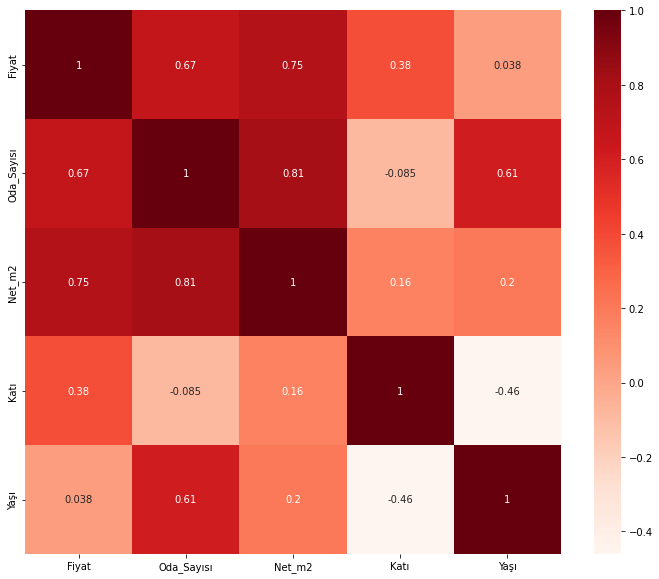

In [16]:
plt.figure(figsize=(12,10))
corr = data.corr()
sns.heatmap(corr,annot = True,cmap = plt.cm.Reds)
plt.show()

c:\Users\oktay\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Fiyat', ylabel='Count'>

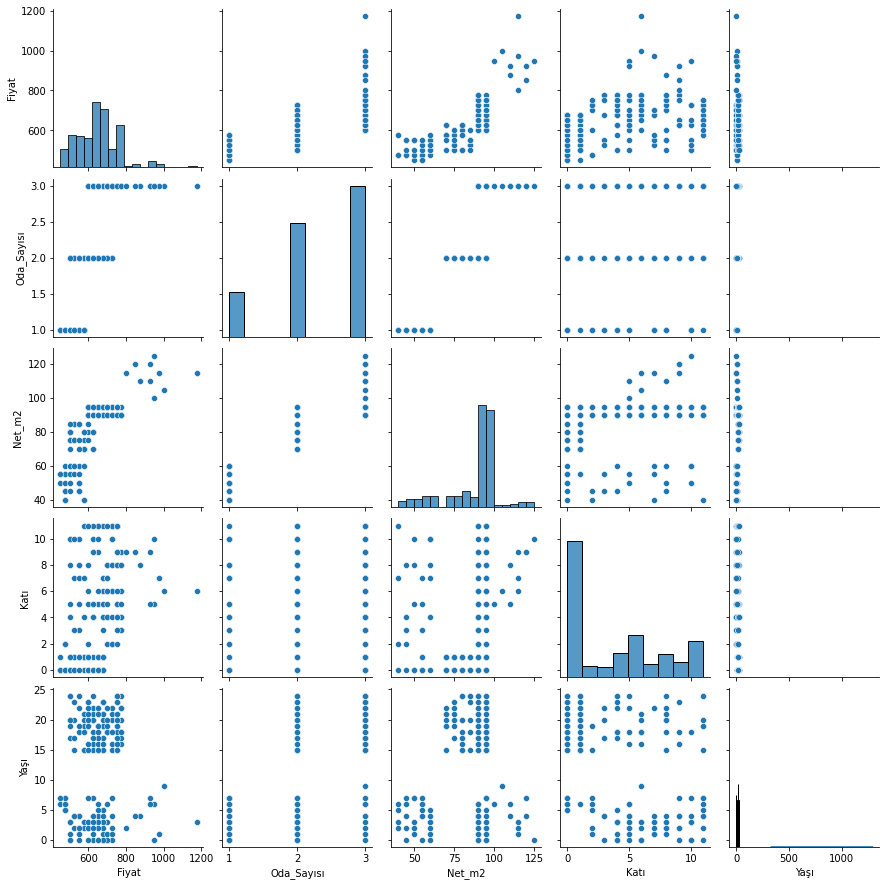

In [17]:
sns.pairplot(data)
sns.distplot(data['Fiyat'])

In [18]:
x = data[['Oda_Sayısı','Net_m2','Katı','Yaşı']]
y = data['Fiyat']

In [19]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [21]:
model.intercept_

305.1625895287759

In [22]:
coeff_df = pd.DataFrame(model.coef_,x.columns,columns = ['feature_coefficients'])
coeff_df

,feature_coefficients
Oda_Sayısı,118.350670
Net_m2,1.133092
Katı,7.096886
Yaşı,-4.665706


#### y = 305,35 + 118,35(Oda Sayısı)+1,133(Net_m2)+7,096(Katı)-4,665(Yaşı)

In [23]:
y_pred_train = model.predict(x_train)
for i,prediction in enumerate(y_pred_train):
    print('Guess house price : %.2f , Real House Price %s'% (prediction,y[i]))

Guess house price : 551.96 , Real House Price 475
Guess house price : 686.31 , Real House Price 475
Guess house price : 531.30 , Real House Price 450
Guess house price : 694.64 , Real House Price 450
Guess house price : 675.66 , Real House Price 475
Guess house price : 698.38 , Real House Price 475
Guess house price : 558.29 , Real House Price 475
Guess house price : 678.21 , Real House Price 475
Guess house price : 546.29 , Real House Price 450
Guess house price : 680.84 , Real House Price 475
Guess house price : 845.06 , Real House Price 475
Guess house price : 546.29 , Real House Price 525
Guess house price : 746.94 , Real House Price 550
Guess house price : 562.47 , Real House Price 575
Guess house price : 553.19 , Real House Price 550
Guess house price : 693.21 , Real House Price 575
Guess house price : 533.30 , Real House Price 500
Guess house price : 688.54 , Real House Price 550
Guess house price : 668.88 , Real House Price 525
Guess house price : 548.47 , Real House Price 500


In [24]:
from sklearn.metrics import r2_score
r2_score(y_train,y_pred_train)

0.733739961656849

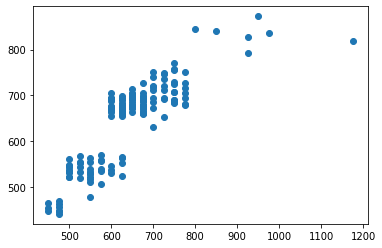

In [25]:
plt.scatter(y_train,y_pred_train)

In [26]:
y_pred_test = model.predict(x_test)
for i,prediction in enumerate(y_pred_test):
    print('Guess house price : %.2f , Real House Price %s'% (prediction,y[i]))

Guess house price : 706.60 , Real House Price 475
Guess house price : 654.37 , Real House Price 475
Guess house price : 747.75 , Real House Price 450
Guess house price : 692.29 , Real House Price 450
Guess house price : 720.48 , Real House Price 475
Guess house price : 537.57 , Real House Price 475
Guess house price : 459.70 , Real House Price 475
Guess house price : 521.32 , Real House Price 475
Guess house price : 669.88 , Real House Price 450
Guess house price : 686.31 , Real House Price 475
Guess house price : 682.88 , Real House Price 475
Guess house price : 720.79 , Real House Price 525
Guess house price : 488.46 , Real House Price 550
Guess house price : 725.65 , Real House Price 575
Guess house price : 686.31 , Real House Price 550
Guess house price : 781.01 , Real House Price 575
Guess house price : 725.65 , Real House Price 500
Guess house price : 696.95 , Real House Price 550
Guess house price : 716.93 , Real House Price 525
Guess house price : 518.53 , Real House Price 500


In [27]:
r2_score(y_test,y_pred_test)

0.6987282352837992

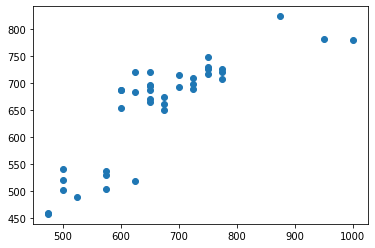

In [28]:
plt.scatter(y_test,y_pred_test)